In [2]:
import numpy as np
import matplotlib.pyplot as plt
from empymod import bipole


:: empymod END; runtime = 0:00:00.146863 :: 768 kernel call(s)



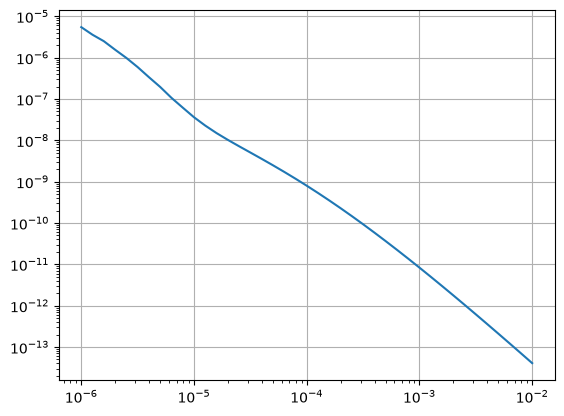

In [ ]:
def forward(res, thk, L=40, time=None):
    """DO something.

    Parameter
    ---------
    res : array
        this is my resistivity (but only subsurface)
    """
    if time is None:
        time = np.logspace(-6, -2, 41)

    tx = [-L/2, L/2, L/2, -L/2, -L/2]
    ty = [L/2, L/2, -L/2, -L/2, L/2]
    out = bipole(res=[2e14, 100, 10], # np.concatenate([2e14, res])
        depth=[0, 30], # convert thickness into depths! (cumsum) [0], cumsum(...)
        src=[tx[:-1], tx[1:], ty[:-1], ty[1:], 0, 0],
        rec=[0, 0, 0, 0, 90],
        signal=-1,
        strength=1/L**2,
        mrec="b",
        freqtime=time, # Wanted times.
        srcpts=3,
        ftarg={"dlf": "key_81_2009"},  # Shorter, faster filters.
        htarg={"dlf": "key_101_2009", "pts_per_dec": -1},
        ).sum(axis=1)

out = forward(...)
plt.loglog(time, out)
plt.grid();

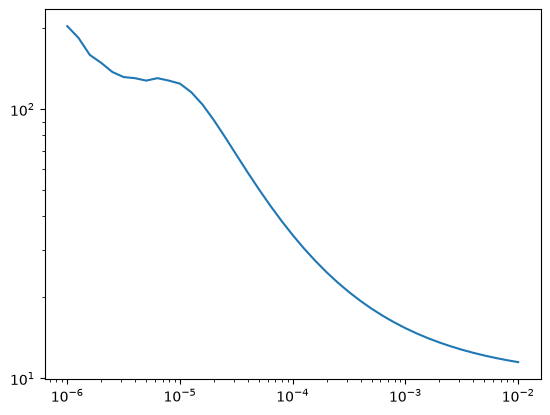

In [30]:
def rhoa(t, dbzdt, m=1.0):
    mu0 = 4e-7 * np.pi
    return mu0/np.pi*(mu0*m/20)**(2/3)*np.abs(dbzdt)**(-2/3)*t**(-5/3)

plt.loglog(time, rhoa(time, out))